# A. Linear Regression (Single Feature). #

## 1.1 Load Dataset and Exploratory Data Analysis

In [1]:
#-- Import Python Library. ---#
import pandas as pd
#-- Import dataset. --#
medical_dataset = pd.read_csv('Medical_insurance.csv')
#-- Print first five rows. --#
medical_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
#-- Print the last five rows of the dataset. --#
medical_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [3]:
#-- Print the information of the dataset, --#
medical_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [4]:
#-- Print the statistical summary of the dataset. --#
medical_dataset.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
#-- Checking sum of null value. --#
medical_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
# --- Check Outliers using IQR method and Boxplot visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
#-- Count and print the number of outliers for numerical columns. --#
numeric_cols = ['age', 'bmi', 'children', 'charges']
print("--- Outliers Statistics ---")
for col in numeric_cols:
    Q1 = medical_dataset[col].quantile(0.25)
    Q3 = medical_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = medical_dataset[(medical_dataset[col] < lower_bound) | (medical_dataset[col] > upper_bound)]
    print(f"Column {col}: {len(outliers)} outliers (Upper bound: {upper_bound:.2f})")

--- Outliers Statistics ---
Column age: 0 outliers (Upper bound: 88.50)
Column bmi: 14 outliers (Upper bound: 47.60)
Column children: 0 outliers (Upper bound: 5.00)
Column charges: 296 outliers (Upper bound: 34412.75)


**Outliers Analysis Insights:**
* **First**, both `age` and `children` features show $0$ outliers, indicating a stable and evenly distributed range across the dataset without abnormal records.
* **Furthermore**, there are $14$ outliers exceeding the upper bound of $47.60$ for the `bmi` feature; **therefore**, these represent extreme cases of severe obesity in real-world medical data rather than data entry errors.
* **In addition**, a total of $296$ outliers are detected above the $34,412.75$ threshold for the `charges` target variable, **meaning that** this right-skewed distribution is typical for medical insurance costs, reflecting expensive treatments, major surgeries, or critical health conditions for a small portion of policyholders.
* **Consequently**, since these values represent true clinical and financial realities rather than artifacts or noise, I retain them in the dataset for subsequent linear regression modeling.

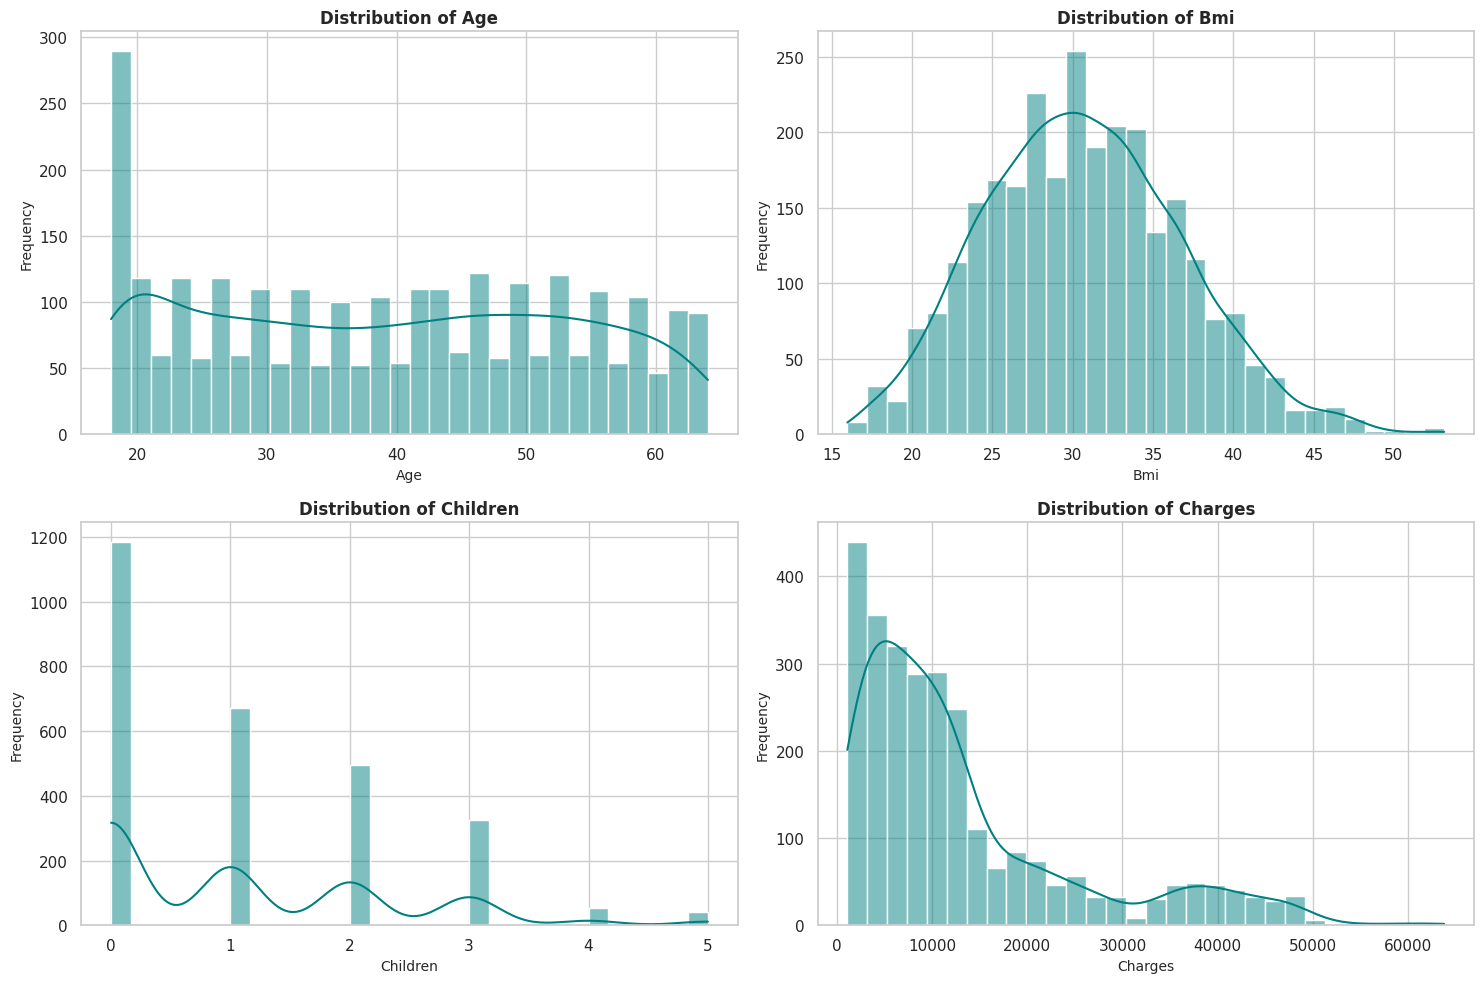

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic plots
sns.set_theme(style="whitegrid")

# 1. Plot histograms with KDE for numerical features
plt.figure(figsize=(15, 10))

numeric_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(medical_dataset[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col.capitalize()}', fontsize=12, fontweight='bold')
    plt.xlabel(col.capitalize(), fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

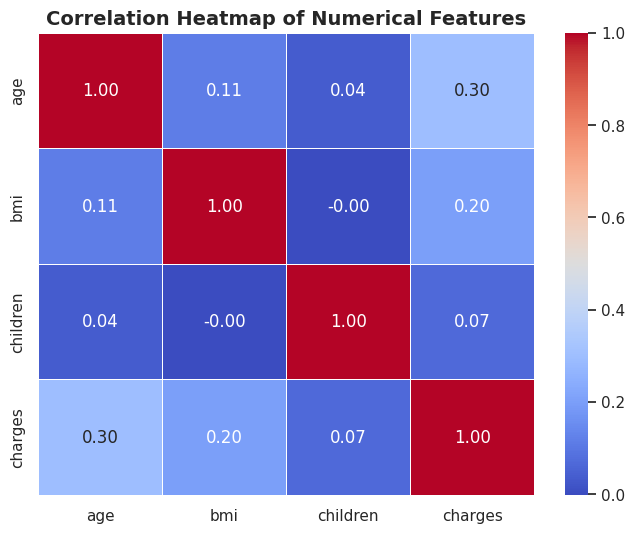

In [8]:
#-- Correlation Matrix. --#
plt.figure(figsize=(8, 6))
correlation_matrix = medical_dataset[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

**Correlation Heatmap Insights:**
* **First**, `age` shows the highest positive linear correlation with medical charges ($0.30$), indicating that older policyholders tend to incur higher insurance costs[cite: 3].
* **Moreover**, `bmi` has a moderate positive correlation with charges ($0.20$), reflecting that a higher body mass index is associated with increased medical expenses[cite: 3].
* **In addition**, other numerical pairs (such as `age` and `bmi` at $0.11$, or `children` and `charges` at $0.07$) exhibit weak correlations, confirming that multicollinearity is minimal among these input features[cite: 3].

=> **Conclusion for Single Feature Modeling:**
**Based on** the correlation analysis above, **`age`** exhibits the strongest positive linear correlation with the target variable, making it the most suitable input feature. **Consequently**, I will proceed to **predict `charges` based on `age`** for the upcoming Single Feature Linear Regression model.

## 1.2 Data Processing. ##

In [11]:
#-- Check categorical columns. --#
categorical_cols = ['sex', 'smoker', 'region']
print("Categorical columns:", categorical_cols)
#-- Apply One-Hot Encoding to categorical variables (drop_first=True to avoid multicollinearity). --#
df_encoded = pd.get_dummies(medical_dataset, columns=categorical_cols, drop_first=True)
#-- Display the first few rows of the encoded dataset. --#
print("\n--- Encoded Dataset Preview ---")
display(df_encoded.head())

Categorical columns: ['sex', 'smoker', 'region']

--- Encoded Dataset Preview ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


**Data Preprocessing Insights:**
* **First**, since machine learning algorithms require numerical inputs rather than strings, I applied **One-Hot Encoding** using `pd.get_dummies()` on categorical features such as `sex`, `smoker`, and `region`.
* **Second**, I used `drop_first=True` for the encoding process to prevent the dummy variable trap and minimize potential multicollinearity.
* **Consequently**, the dataset is now fully transformed into a numerical format, making it ready for feature scaling, data splitting, and subsequent linear regression modeling.

## 1.3 Split Train/Test Dataset. ##

In [12]:
# --- Train/Test Split and Scaling for Single Feature ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#-- Define target variable (y) and single feature (X). --#
y = df_encoded['charges']
X_single = df_encoded[['age']]
#-- Split dataset into training (80%) and testing (20%) sets. --#
X_train_single, X_test_single, y_train_s, y_test_s = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)
#-- Scale the single feature using StandardScaler. --#
scaler_single = StandardScaler()
X_train_single_scaled = scaler_single.fit_transform(X_train_single)
X_test_single_scaled = scaler_single.transform(X_test_single)
print(f"Single Feature Training set shape: {X_train_single_scaled.shape}")

Single Feature Training set shape: (2217, 1)


## 1.4 Training and Evaluating. ##

In [15]:
# --- Single Feature Linear Regression Training & Evaluation ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
#-- Initialize and train the model using 'age'. --#
lr_single_model = LinearRegression()
lr_single_model.fit(X_train_single_scaled, y_train_s)
#-- Predict on the test set. --#
y_pred_single = lr_single_model.predict(X_test_single_scaled)
#-- Evaluate performance metrics (MAE, RMSE). --#
mae_single = mean_absolute_error(y_test_s, y_pred_single)
rmse_single = np.sqrt(mean_squared_error(y_test_s, y_pred_single))
print(f"--- Single Feature Linear Regression Results ---")
print(f"Intercept: {lr_single_model.intercept_:.2f}")
print(f"Coefficient (Age): {lr_single_model.coef_[0]:.2f}")
print(f"Mean Absolute Error (MAE): {mae_single:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_single:.2f}")

--- Single Feature Linear Regression Results ---
Intercept: 13371.07
Coefficient (Age): 3424.48
Mean Absolute Error (MAE): 9025.41
Root Mean Squared Error (RMSE): 11617.97


## 1.5 Data Visualization. ##

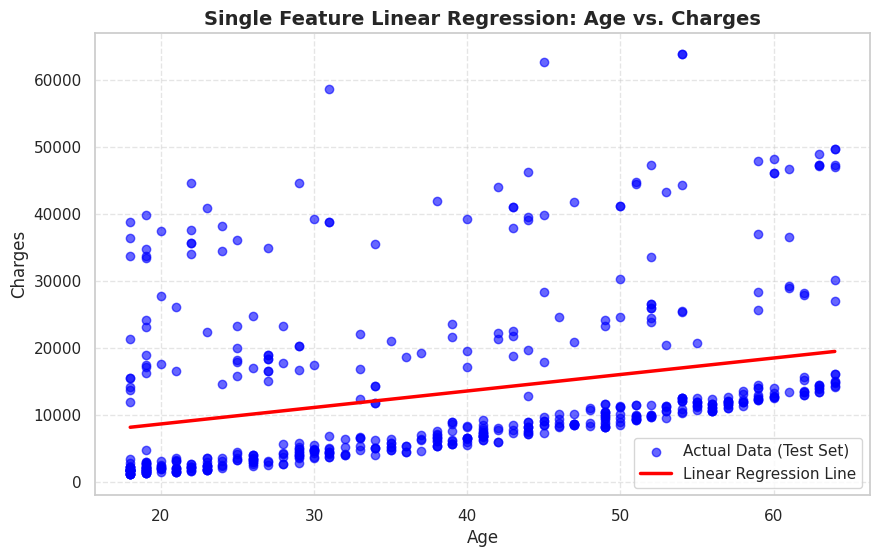

In [17]:
# --- Visualization for Single Feature Linear Regression --- #
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
#-- Plot actual test data points. --#
plt.scatter(X_test_single, y_test_s, color='blue', alpha=0.6, label='Actual Data (Test Set)')
#-- Plot regression line (need to inverse transform or sort for smooth plotting). --#
#-- Sort X_test for a clean regression line plot. --#
sort_idx = X_test_single['age'].argsort()
plt.plot(X_test_single.iloc[sort_idx], y_pred_single[sort_idx], color='red', linewidth=2.5, label='Linear Regression Line')
plt.title('Single Feature Linear Regression: Age vs. Charges', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# B. Multiple Linear Regression. #

## 2.1 Split Train/Test Dataset. ##

In [13]:
# --- Train/Test Split and Scaling for Multiple Features ---
#-- Define multi-feature input (drop target column). --#
X_multi = df_encoded.drop(columns=['charges'])
#-- Split dataset into training (80%) and testing (20%) sets. --#
X_train_multi, X_test_multi, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)
#-- Scale all features using StandardScaler. --#
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)
print(f"Multiple Features Training set shape: {X_train_multi_scaled.shape}")

Multiple Features Training set shape: (2217, 8)


## 2.2 Train Model and Evaluate. ##

In [16]:
# --- Multiple Features Linear Regression Training & Evaluation --- #
#-- Initialize and train the model using all features. --#
lr_multi_model = LinearRegression()
lr_multi_model.fit(X_train_multi_scaled, y_train_m)
#-- Predict on the test set. --#
y_pred_multi = lr_multi_model.predict(X_test_multi_scaled)
#-- Evaluate performance metrics (MAE, RMSE, R2 Score). --#
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_multi = lr_multi_model.score(X_test_multi_scaled, y_test_m)
print(f"--- Multiple Features Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae_multi:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multi:.2f}")
print(f"R-squared (R2) Score: {r2_multi:.4f}")

--- Multiple Features Linear Regression Results ---
Mean Absolute Error (MAE): 4160.25
Root Mean Squared Error (RMSE): 6319.27
R-squared (R2) Score: 0.7398


## 2.3 Data Visualization. ##

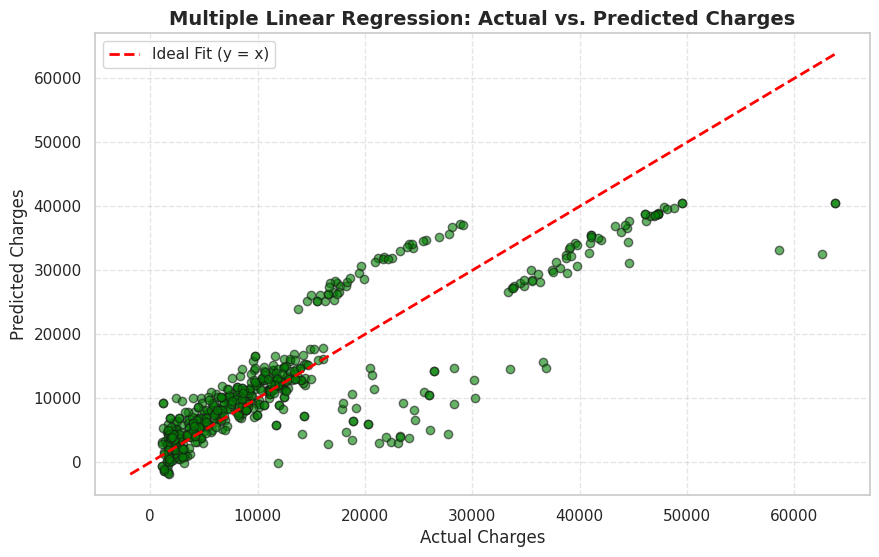

In [18]:
#--- Visualization for Multiple Features Linear Regression (Actual vs Predicted) ---#
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_multi, color='green', alpha=0.6, edgecolors='k')
#-- Plot ideal line (y = x) for perfect predictions. --#
min_val = min(y_test_m.min(), y_pred_multi.min())
max_val = max(y_test_m.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')
plt.title('Multiple Linear Regression: Actual vs. Predicted Charges', fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges', fontsize=12)
plt.ylabel('Predicted Charges', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()